In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("bike_buyers_clean.csv")

In [3]:
print(df.head())

      ID Marital Status  Gender  Income  Children        Education  \
0  12496        Married  Female   40000         1        Bachelors   
1  24107        Married    Male   30000         3  Partial College   
2  14177        Married    Male   80000         5  Partial College   
3  24381         Single    Male   70000         0        Bachelors   
4  25597         Single    Male   30000         0        Bachelors   

       Occupation Home Owner  Cars Commute Distance   Region  Age  \
0  Skilled Manual        Yes     0        0-1 Miles   Europe   42   
1        Clerical        Yes     1        0-1 Miles   Europe   43   
2    Professional         No     2        2-5 Miles   Europe   60   
3    Professional        Yes     1       5-10 Miles  Pacific   41   
4        Clerical         No     0        0-1 Miles   Europe   36   

  Purchased Bike  
0             No  
1             No  
2             No  
3            Yes  
4            Yes  


In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1000, 13)


In [5]:
print(df.columns)


Index(['ID', 'Marital Status', 'Gender', 'Income', 'Children', 'Education',
       'Occupation', 'Home Owner', 'Cars', 'Commute Distance', 'Region', 'Age',
       'Purchased Bike'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ID                1000 non-null   int64 
 1   Marital Status    1000 non-null   object
 2   Gender            1000 non-null   object
 3   Income            1000 non-null   int64 
 4   Children          1000 non-null   int64 
 5   Education         1000 non-null   object
 6   Occupation        1000 non-null   object
 7   Home Owner        1000 non-null   object
 8   Cars              1000 non-null   int64 
 9   Commute Distance  1000 non-null   object
 10  Region            1000 non-null   object
 11  Age               1000 non-null   int64 
 12  Purchased Bike    1000 non-null   object
dtypes: int64(5), object(8)
memory usage: 101.7+ KB


In [7]:
df.describe()

,ID,Income,Children,Cars,Age
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,19965.992000,56140.000000,1.908000,1.452000,44.190000
std,5347.333948,31081.609779,1.626094,1.124705,11.353537
min,11000.000000,10000.000000,0.000000,0.000000,25.000000
25%,15290.750000,30000.000000,0.000000,1.000000,35.000000
50%,19744.000000,60000.000000,2.000000,1.000000,43.000000
75%,24470.750000,70000.000000,3.000000,2.000000,52.000000
max,29447.000000,170000.000000,5.000000,4.000000,89.000000


1. Central Tendency


CENTRAL TENDENCY OF INCOME
Mean: 56140.0
Median: 60000.0
Mode: 60000


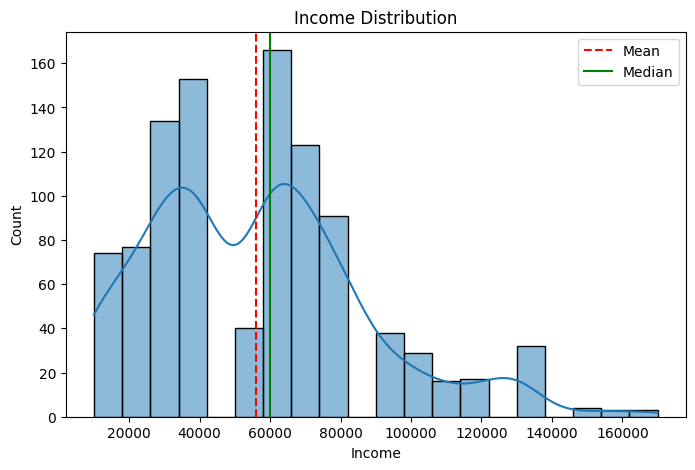

In [8]:
print("\nCENTRAL TENDENCY OF INCOME")

print("Mean:", df['Income'].mean())
print("Median:", df['Income'].median())
print("Mode:", df['Income'].mode()[0])

plt.figure(figsize=(8,5))

sns.histplot(df['Income'], kde=True)

plt.axvline(df['Income'].mean(),
            color='red',
            linestyle='--',
            label='Mean')

plt.axvline(df['Income'].median(),
            color='green',
            linestyle='-',
            label='Median')

plt.title("Income Distribution")
plt.legend()

plt.show()



CENTRAL TENDENCY OF INCOME with Violin Plot
Mean: 57170.0
Median: 60000.0
Mode: 60000


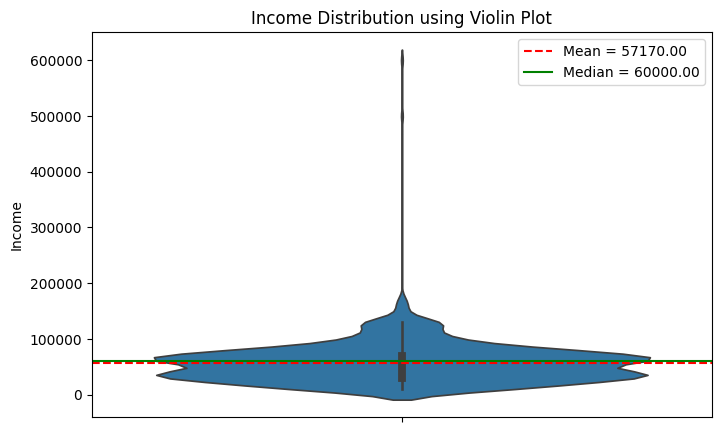

In [13]:
print("\nCENTRAL TENDENCY OF INCOME with Violin Plot")

mean_income = df['Income'].mean()
median_income = df['Income'].median()
mode_income = df['Income'].mode()[0]

print("Mean:", mean_income)
print("Median:", median_income)
print("Mode:", mode_income)

plt.figure(figsize=(8,5))

sns.violinplot(y=df['Income'])

plt.axhline(
    mean_income,
    color='red',
    linestyle='--',
    label=f'Mean = {mean_income:.2f}'
)

plt.axhline(
    median_income,
    color='green',
    linestyle='-',
    label=f'Median = {median_income:.2f}'
)

plt.title("Income Distribution using Violin Plot")
plt.ylabel("Income")
plt.legend()

plt.show()

2.Outlier identification (Visual ; Numeric). Add outliers if the dataset does not have any.




Number of Outliers: 12

Outlier Values:
     Income
0    500000
1    600000
6    160000
12   170000
43   170000
121  150000
178  160000
259  150000
321  160000
356  150000
829  170000
993  150000


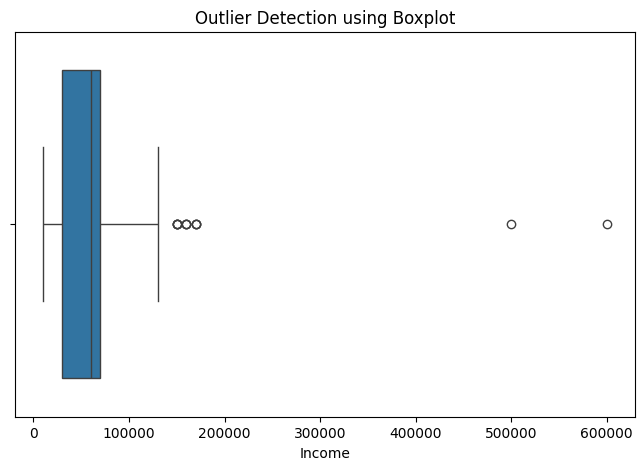

In [9]:
df.loc[0, 'Income'] = 500000
df.loc[1, 'Income'] = 600000

Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['Income'] < lower_bound) |
    (df['Income'] > upper_bound)
]

print("\nNumber of Outliers:", len(outliers))

print("\nOutlier Values:")
print(outliers[['Income']])

plt.figure(figsize=(8,5))

sns.boxplot(x=df['Income'])

plt.title("Outlier Detection using Boxplot")

plt.show()

3. Visualizing relationship between 2 numeric variables


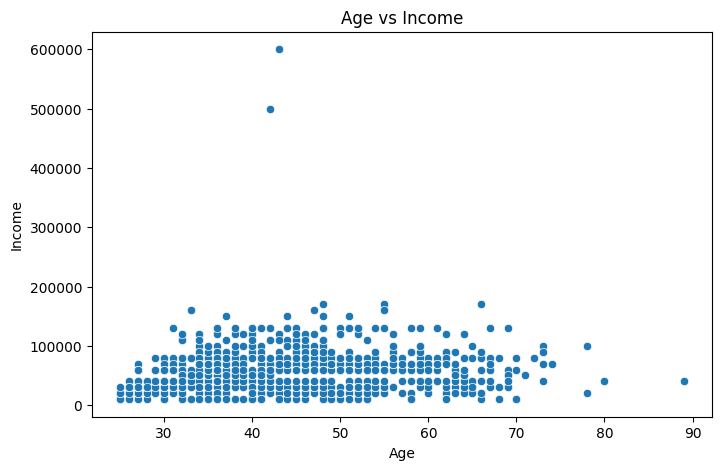


Correlation:
             Age    Income
Age     1.000000  0.133808
Income  0.133808  1.000000


In [10]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Age',
    y='Income'
)

plt.title("Age vs Income")

plt.show()

print("\nCorrelation:")

print(
    df[['Age','Income']].corr()
)

4. Visualizing relationship between numeric and nominal variable


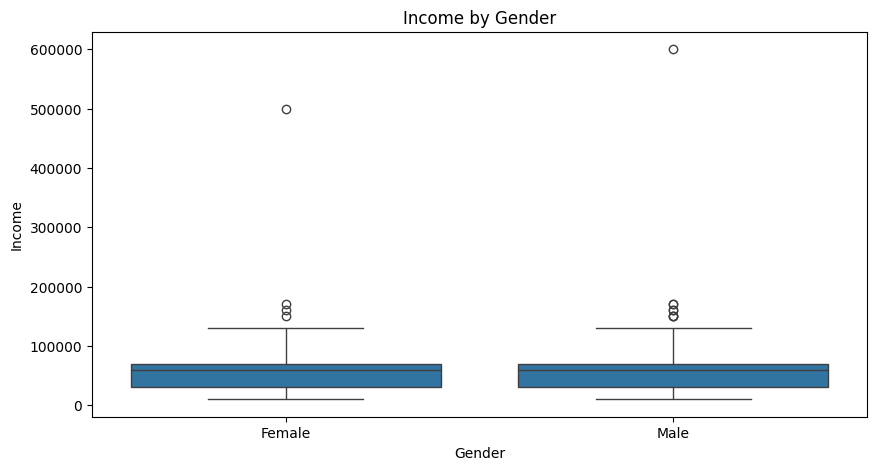

        count          mean           std      min      25%      50%      75%  \
Gender                                                                          
Female  491.0  55560.081466  36759.587882  10000.0  30000.0  60000.0  70000.0   
Male    509.0  58722.986248  39466.669409  10000.0  30000.0  60000.0  70000.0   

             max  
Gender            
Female  500000.0  
Male    600000.0  


In [11]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='Gender',
    y='Income'
)

plt.title("Income by Gender")

plt.show()

print(
    df.groupby('Gender')['Income']
      .describe()
)

5. Visualizing relationship between two nominal variables.



Cross Tabulation
Purchased Bike   No  Yes
Gender                  
Female          252  239
Male            267  242


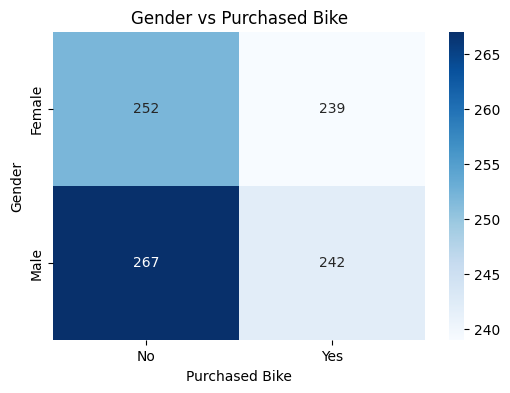

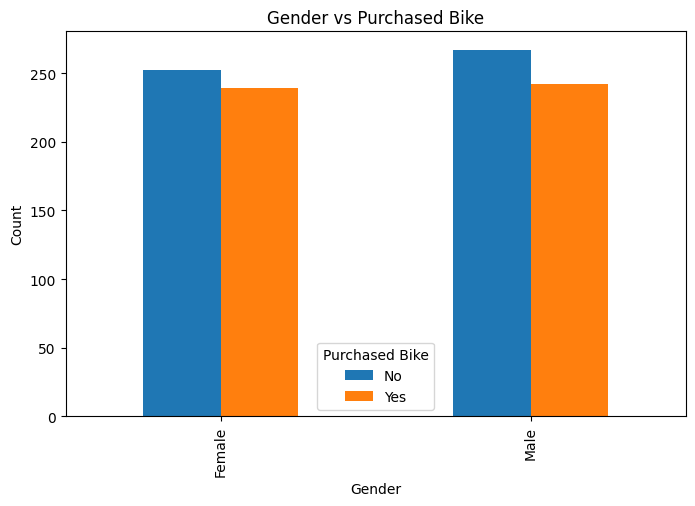

In [12]:
cross_tab = pd.crosstab(
    df['Gender'],
    df['Purchased Bike']
)

print("\nCross Tabulation")

print(cross_tab)

plt.figure(figsize=(6,4))

sns.heatmap(
    cross_tab,
    annot=True,
    cmap='Blues',
    fmt='d'
)

plt.title("Gender vs Purchased Bike")

plt.show()

# Alternative Bar Chart

cross_tab.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Gender vs Purchased Bike")

plt.ylabel("Count")

plt.show()